# Assignment 2: Effect of Conv Output Channels on LeNet-5

How do the output channels of conv1 (`c1`) and conv2 (`c2`) affect accuracy, size and training time? Baseline from slide 17: `c1=6, c2=16`.

- Architecture: conv(5×5, pad 2) → ReLU → maxpool 2 → conv(5×5) → ReLU → maxpool 2 → **one FC** (`c2·5·5 → 10`), as on the slide. ReLU and max pooling are my choices; no 120/84 layers.
- MNIST 60k/10k, normalized (0.1307, 0.3081). Adam, lr 1e-3, batch 128, 10 epochs, cross-entropy, seeds 0/1/2. No tuning.
- Sweeps: **A** `c1 ∈ {2,4,6,12,24}`, `c2=16` · **B** `c2 ∈ {4,8,16,32,64}`, `c1=6` · **C** `(c1,c2) ∈ {(3,8),(6,16),(12,32),(24,64)}`.

## 1. Setup

In [1]:
import time, random
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F
from torchvision import datasets
from scipy import stats

device = torch.device("cuda" if torch.cuda.is_available() else
                      "mps" if torch.backends.mps.is_available() else "cpu")
LR, BATCH, SEEDS = 1e-3, 128, [0, 1, 2]
EPOCHS = 10 if device.type != "cpu" else 5          # CPU only: 5 epochs
if device.type == "cpu": print("No GPU: EPOCHS reduced to 5.")

def set_seed(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)   # torch seed also covers CUDA/MPS

def sync():  # wait for the GPU so timings are correct
    if device.type == "cuda": torch.cuda.synchronize()
    elif device.type == "mps": torch.mps.synchronize()

print(device, EPOCHS)

mps 10


## 2. Data
The full dataset is moved to the device once and batched by index. This is faster than a `DataLoader`. Preprocessing is the same as `ToTensor()` + `Normalize()`.

In [2]:
def load(train):
    ds = datasets.MNIST("data", train=train, download=True)
    x = (ds.data.float().div(255).unsqueeze(1) - 0.1307) / 0.3081   # [N,1,28,28]
    return x.to(device), ds.targets.to(device)

X_tr, y_tr = load(True)
X_te, y_te = load(False)
print(X_tr.shape, X_te.shape)

torch.Size([60000, 1, 28, 28]) torch.Size([10000, 1, 28, 28])


## 3. Model

In [3]:
class LeNet5(nn.Module):
    def __init__(self, c1=6, c2=16):
        super().__init__()
        self.conv1 = nn.Conv2d(1, c1, 5, padding=2)   # -> c1x28x28
        self.conv2 = nn.Conv2d(c1, c2, 5)             # -> c2x10x10
        self.pool = nn.MaxPool2d(2)
        self.fc = nn.Linear(c2 * 5 * 5, 10)           # FC input computed from c2

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        return self.fc(torch.flatten(x, 1))

def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

In [4]:
# Shape check: print the shape after each layer
def shape_check(c1, c2):
    m, x = LeNet5(c1, c2), torch.zeros(1, 1, 28, 28)
    print(f"LeNet5({c1},{c2}): {count_params(m):,} params")
    for name, f in [("conv1", lambda t: F.relu(m.conv1(t))), ("pool1", m.pool),
                    ("conv2", lambda t: F.relu(m.conv2(t))), ("pool2", m.pool),
                    ("flatten", lambda t: t.flatten(1)), ("fc", m.fc)]:
        x = f(x); print(f"  {name:8s}{tuple(x.shape[1:])}")

shape_check(6, 16)
for c1, c2 in [(6, 4), (6, 64), (24, 64)]:          # other c2 values must not break the FC layer
    assert LeNet5(c1, c2)(torch.zeros(2, 1, 28, 28)).shape == (2, 10)
print("FC layer works for c2 = 4, 64")

LeNet5(6,16): 6,582 params
  conv1   (6, 28, 28)
  pool1   (6, 14, 14)
  conv2   (16, 10, 10)
  pool2   (16, 5, 5)
  flatten (400,)
  fc      (10,)
FC layer works for c2 = 4, 64


## 4. Train and evaluate
Training time counts only the training steps. The test evaluation after each epoch (for learning curves) is not timed.

In [5]:
@torch.no_grad()
def evaluate(m):
    m.eval()
    return sum((m(X_te[i:i+2000]).argmax(1) == y_te[i:i+2000]).sum().item()
               for i in range(0, len(X_te), 2000)) / len(X_te)

def train_epoch(m, opt, gen):
    m.train()
    perm = torch.randperm(len(X_tr), generator=gen).to(device)   # seeded shuffle
    tot = torch.zeros((), device=device)
    for i in range(0, len(perm), BATCH):
        idx = perm[i:i+BATCH]
        loss = F.cross_entropy(m(X_tr[idx]), y_tr[idx])
        opt.zero_grad(); loss.backward(); opt.step()
        tot += loss.detach() * len(idx)
    return (tot / len(X_tr)).item()                               # mean train loss of the epoch

## 5. Experiment runner
Runs are cached by `(c1, c2, seed)`, so the baseline is trained once per seed and reused in all three sweeps.

In [6]:
CACHE = {}

def run(c1, c2, seed):
    if (c1, c2, seed) not in CACHE:
        set_seed(seed)
        m = LeNet5(c1, c2).to(device)
        opt = torch.optim.Adam(m.parameters(), lr=LR)
        gen = torch.Generator().manual_seed(seed)
        t, accs, loss = 0.0, [], None
        for _ in range(EPOCHS):
            sync(); t0 = time.perf_counter()
            loss = train_epoch(m, opt, gen)
            sync(); t += time.perf_counter() - t0
            accs.append(evaluate(m))
        CACHE[(c1, c2, seed)] = dict(c1=c1, c2=c2, seed=seed, params=count_params(m),
                                     acc=100 * accs[-1], loss=loss, time=t, curve=accs)
    return CACHE[(c1, c2, seed)]

## 6. Run sweeps

In [7]:
SWEEPS = {"A": [(c, 16) for c in [2, 4, 6, 12, 24]],
          "B": [(6, c) for c in [4, 8, 16, 32, 64]],
          "C": [(3, 8), (6, 16), (12, 32), (24, 64)]}
BASE = (6, 16)

t0 = time.perf_counter()
for name, cfgs in SWEEPS.items():
    for c1, c2 in cfgs:
        r = [run(c1, c2, s) for s in SEEDS]
        print(f"{name} ({c1:2d},{c2:2d})  acc {np.mean([x['acc'] for x in r]):.2f}%  "
              f"time {np.mean([x['time'] for x in r]):.1f}s")
print(f"{len(CACHE)} runs in {(time.perf_counter() - t0) / 60:.1f} min")

A ( 2,16)  acc 98.68%  time 9.0s


A ( 4,16)  acc 98.77%  time 9.8s


A ( 6,16)  acc 98.85%  time 10.4s


A (12,16)  acc 98.88%  time 12.8s


A (24,16)  acc 99.01%  time 16.9s


...

B ( 6,32)  acc 98.96%  time 11.3s


B ( 6,64)  acc 99.09%  time 13.8s


C ( 3, 8)  acc 98.43%  time 9.3s
C ( 6,16)  acc 98.85%  time 10.4s


C (12,32)  acc 99.01%  time 15.5s


C (24,64)  acc 99.09%  time 23.4s
36 runs in 7.8 min


## 7. Results

In [8]:
runs = pd.DataFrame(CACHE.values())
res = (runs.groupby(["c1", "c2"])
           .agg(params=("params", "first"), acc_mean=("acc", "mean"), acc_std=("acc", "std"),
                loss_mean=("loss", "mean"), loss_std=("loss", "std"),
                time_mean=("time", "mean"), time_std=("time", "std"))
           .reset_index().sort_values("params", ignore_index=True))
res["baseline"] = [(a, b) == BASE for a, b in zip(res.c1, res.c2)]
res.to_csv("results.csv", index=False)
res.round(3)

,c1,c2,params,acc_mean,acc_std,loss_mean,loss_std,time_mean,time_std,baseline
0,6,4,1770,98.240,0.092,0.058,0.001,9.329,0.120,False
1,3,8,2696,98.430,0.082,0.049,0.003,9.325,0.113,False
2,6,8,3374,98.527,0.123,0.041,0.004,10.170,0.321,False
3,2,16,4878,98.677,0.035,0.039,0.001,9.011,0.352,False
4,4,16,5730,98.770,0.095,0.030,0.001,9.790,0.164,False
5,6,16,6582,98.853,0.116,0.027,0.001,10.437,0.232,True
6,12,16,9138,98.877,0.087,0.021,0.001,12.824,0.435,False
7,6,32,12998,98.960,0.079,0.017,0.001,11.309,0.044,False
8,24,16,14250,99.013,0.158,0.018,0.001,16.852,0.126,False
9,12,32,17954,99.007,0.153,0.013,0.001,15.498,0.262,False


In [9]:
def sweep_table(name):
    t = res.set_index(["c1", "c2"]).loc[SWEEPS[name]].reset_index()
    return pd.DataFrame({
        "config": [f"({a},{b})" + (" *" if (a, b) == BASE else "") for a, b in zip(t.c1, t.c2)],
        "params": t.params,
        "acc %": [f"{m:.2f} ± {s:.2f}" for m, s in zip(t.acc_mean, t.acc_std)],
        "train loss": [f"{m:.4f} ± {s:.4f}" for m, s in zip(t.loss_mean, t.loss_std)],
        "time s": [f"{m:.1f} ± {s:.1f}" for m, s in zip(t.time_mean, t.time_std)]})

for n in SWEEPS:
    print(f"Sweep {n}  (* = baseline)"); display(sweep_table(n).style.hide(axis="index"))

Sweep A  (* = baseline)


config,params,acc %,train loss,time s
"(2,16)",4878,98.68 ± 0.04,0.0386 ± 0.0012,9.0 ± 0.4
"(4,16)",5730,98.77 ± 0.10,0.0296 ± 0.0012,9.8 ± 0.2
"(6,16) *",6582,98.85 ± 0.12,0.0269 ± 0.0007,10.4 ± 0.2
"(12,16)",9138,98.88 ± 0.09,0.0209 ± 0.0015,12.8 ± 0.4
"(24,16)",14250,99.01 ± 0.16,0.0175 ± 0.0009,16.9 ± 0.1


Sweep B  (* = baseline)


config,params,acc %,train loss,time s
"(6,4)",1770,98.24 ± 0.09,0.0579 ± 0.0011,9.3 ± 0.1
"(6,8)",3374,98.53 ± 0.12,0.0407 ± 0.0040,10.2 ± 0.3
"(6,16) *",6582,98.85 ± 0.12,0.0269 ± 0.0007,10.4 ± 0.2
"(6,32)",12998,98.96 ± 0.08,0.0173 ± 0.0012,11.3 ± 0.0
"(6,64)",25830,99.09 ± 0.05,0.0113 ± 0.0007,13.8 ± 0.3


Sweep C  (* = baseline)


config,params,acc %,train loss,time s
"(3,8)",2696,98.43 ± 0.08,0.0495 ± 0.0029,9.3 ± 0.1
"(6,16) *",6582,98.85 ± 0.12,0.0269 ± 0.0007,10.4 ± 0.2
"(12,32)",17954,99.01 ± 0.15,0.0133 ± 0.0009,15.5 ± 0.3
"(24,64)",55098,99.09 ± 0.06,0.0083 ± 0.0006,23.4 ± 0.3


## 8. Plots
Error bars show ±1 std over 3 seeds. The star marks the baseline (6, 16).

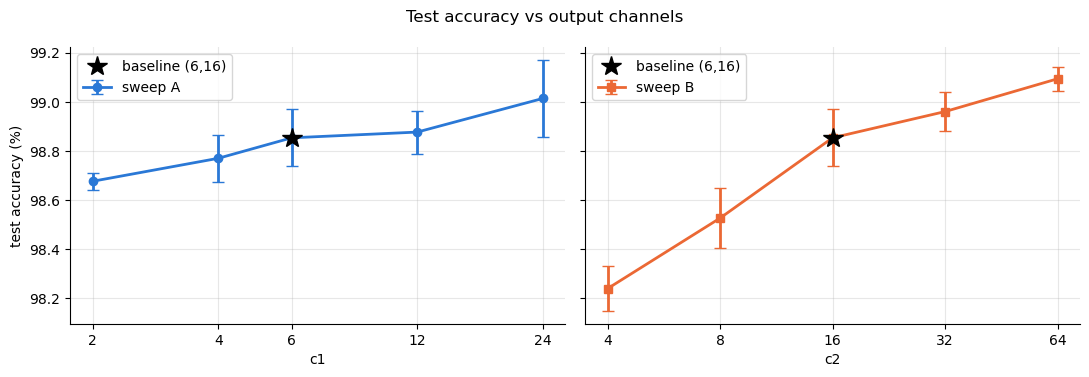

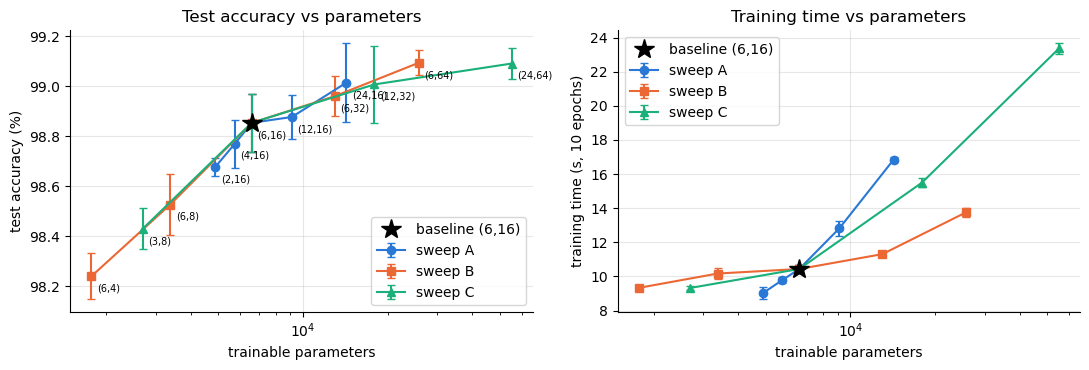

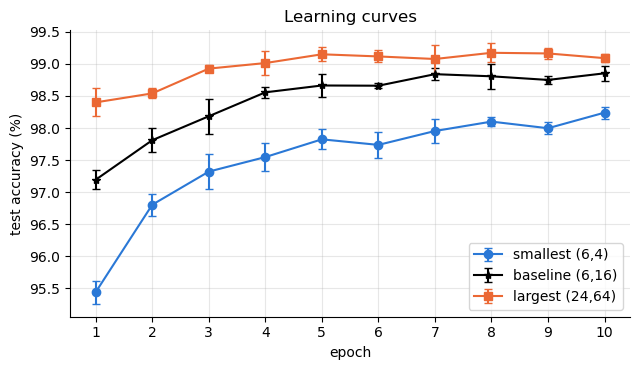

In [10]:
COL = {"A": "#2a78d6", "B": "#eb6834", "C": "#1baf7a"}
MRK = {"A": "o", "B": "s", "C": "^"}
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.alpha": .3})
sub = lambda n: res.set_index(["c1", "c2"]).loc[SWEEPS[n]].reset_index()
b = res[res.baseline].iloc[0]
star = lambda ax, x, y: ax.plot(x, y, "k*", ms=15, zorder=5, label="baseline (6,16)")

# Accuracy vs channels (A, B)
fig, axs = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax, n, v in [(axs[0], "A", "c1"), (axs[1], "B", "c2")]:
    s = sub(n)
    ax.errorbar(s[v], s.acc_mean, s.acc_std, color=COL[n], marker=MRK[n], capsize=4, lw=2, label=f"sweep {n}")
    star(ax, b[v], b.acc_mean)
    ax.set_xscale("log", base=2); ax.set_xticks(s[v], s[v]); ax.set_xlabel(v); ax.legend()
axs[0].set_ylabel("test accuracy (%)"); fig.suptitle("Test accuracy vs output channels")
plt.tight_layout(); plt.show()

# Accuracy and time vs parameters (all configs)
fig, axs = plt.subplots(1, 2, figsize=(11, 3.8))
for n in SWEEPS:
    s = sub(n)
    for ax, y in [(axs[0], "acc"), (axs[1], "time")]:
        ax.errorbar(s.params, s[f"{y}_mean"], s[f"{y}_std"], color=COL[n], marker=MRK[n], capsize=3, label=f"sweep {n}")
star(axs[0], b.params, b.acc_mean); star(axs[1], b.params, b.time_mean)
for _, r in res.iterrows():
    axs[0].annotate(f"({r.c1},{r.c2})", (r.params, r.acc_mean), xytext=(4, -11), textcoords="offset points", fontsize=7)
for ax, t, yl in [(axs[0], "Test accuracy vs parameters", "test accuracy (%)"),
                  (axs[1], "Training time vs parameters", f"training time (s, {EPOCHS} epochs)")]:
    ax.set_xscale("log"); ax.set_xlabel("trainable parameters"); ax.set_ylabel(yl); ax.set_title(t); ax.legend()
plt.tight_layout(); plt.show()

# Learning curves: smallest, baseline, largest
fig, ax = plt.subplots(figsize=(6.5, 3.8))
ep = np.arange(1, EPOCHS + 1)
for (c1, c2), tag, col, mk in [(tuple(res.iloc[0][["c1", "c2"]]), "smallest", COL["A"], "o"),
                               (BASE, "baseline", "k", "*"),
                               (tuple(res.iloc[-1][["c1", "c2"]]), "largest", COL["B"], "s")]:
    c = 100 * np.array([CACHE[(c1, c2, s)]["curve"] for s in SEEDS])
    ax.errorbar(ep, c.mean(0), c.std(0, ddof=1), color=col, marker=mk, capsize=3, label=f"{tag} ({c1},{c2})")
ax.set_xticks(ep); ax.set_xlabel("epoch"); ax.set_ylabel("test accuracy (%)"); ax.set_title("Learning curves"); ax.legend()
plt.tight_layout(); plt.show()

### Comparison with baseline
Welch t-test on 3 seeds per config, so the test has low power. Gain per 1k params = Δacc / Δparams × 1000.

In [11]:
ba = runs[(runs.c1 == 6) & (runs.c2 == 16)].acc.values
cmp = res[["c1", "c2", "params", "acc_mean", "acc_std", "time_mean"]].copy()
cmp["d_acc"] = cmp.acc_mean - b.acc_mean
cmp["d_params"] = cmp.params - b.params
cmp["gain_per_1k"] = (cmp.d_acc / cmp.d_params * 1000).where(cmp.d_params != 0)
cmp["time_ratio"] = cmp.time_mean / b.time_mean
cmp["p_value"] = [np.nan if (a, c) == BASE else
                  stats.ttest_ind(runs[(runs.c1 == a) & (runs.c2 == c)].acc.values, ba, equal_var=False).pvalue
                  for a, c in zip(cmp.c1, cmp.c2)]
cmp.round(3)

,c1,c2,params,acc_mean,acc_std,time_mean,d_acc,d_params,gain_per_1k,time_ratio,p_value
0,6,4,1770,98.240,0.092,9.329,-0.613,-4812,0.127,0.894,0.002
1,3,8,2696,98.430,0.082,9.325,-0.423,-3886,0.109,0.893,0.009
2,6,8,3374,98.527,0.123,10.170,-0.327,-3208,0.102,0.974,0.029
3,2,16,4878,98.677,0.035,9.011,-0.177,-1704,0.104,0.863,0.108
4,4,16,5730,98.770,0.095,9.790,-0.083,-852,0.098,0.938,0.393
5,6,16,6582,98.853,0.116,10.437,0.000,0,NaN,1.000,NaN
6,12,16,9138,98.877,0.087,12.824,0.023,2556,0.009,1.229,0.795
7,6,32,12998,98.960,0.079,11.309,0.107,6416,0.017,1.084,0.267
8,24,16,14250,99.013,0.158,16.852,0.160,7668,0.021,1.615,0.237
9,12,32,17954,99.007,0.153,15.498,0.153,11372,0.013,1.485,0.244


## 9. Analysis

Baseline (6, 16): **98.85 ± 0.12 %**, 6,582 params, 10.4 s. Seed std across configs: 0.04–0.16 pp.

**Saturation.** Accuracy levels off near 99.0–99.1 %. In sweep B each doubling of `c2` adds less: +0.29, +0.33, +0.11, +0.13 pp. (24, 64) reaches 99.09 %, the same as (6, 64), with twice the parameters. Above the baseline no config is significantly better.

**conv1 vs conv2.** conv2 matters more. Sweep B spans 0.85 pp (98.24 → 99.09). Sweep A spans 0.34 pp (98.68 → 99.01). Cutting `c2` to 4 costs 0.61 pp (p = 0.002). Cutting `c1` to 2 costs 0.18 pp (p = 0.11, not significant). Note: `c2` also sets the FC size (`c2·250` weights), so sweep B changes both conv and FC capacity.

**Gain per parameter.** Below the baseline, removing parameters costs about 0.10–0.13 pp per 1k params. Above it, adding parameters gains only 0.005–0.021 pp per 1k params, roughly 5–20× less. The baseline sits near the knee.

**Cost.** Parameters grow linearly with `c2` (conv2 and FC) and with `c1·c2` (conv2). Time depends more on `c1`, because conv1 runs at 28×28. (24, 16) has 14k params and takes 16.9 s. (6, 64) has 26k params and takes 13.8 s, with higher accuracy. (24, 64) takes 23.4 s (2.2× the baseline) for +0.24 pp.

**Significance.** Only the smaller models with `c2 ≤ 8` differ from the baseline at p < 0.05. Every config above the baseline gains ≤ 0.24 pp and is not significant (best: p ≈ 0.05 for (6, 64) and (24, 64)). Gains of 0.02–0.16 pp, e.g. (12, 16) and (24, 16), are within seed noise.

**Limitations.** MNIST is easy, so all configs lie within 1 pp. Training is short (10 epochs), so larger models may not have converged. With 3 seeds the t-test has low power. Timings on MPS vary by up to ~10 % between runs.